# ❤️ Heart Disease Risk Predictor

## What This Project Does
In this project we will build a machine learning model that predicts whether a patient is at **risk of heart disease** based on their health measurements (age, cholesterol, blood pressure, etc.).

This is a **binary classification** problem: for each patient the model outputs either `1` (likely has heart disease) or `0` (unlikely). We will compare two models — Logistic Regression (simple) and Random Forest (more powerful) — and then use a tool called **SHAP** to understand *which features the model relies on most*.

## What You Will Learn
- How to perform **exploratory data analysis (EDA)** to understand a dataset before modelling
- Why **feature scaling** matters for some ML models
- How to compare two different models using **accuracy, ROC-AUC**, and a **classification report**
- What the **ROC-AUC curve** is and how to interpret the AUC score
- How to use **SHAP** to explain which patient features drive the model's predictions

## Dataset
- **Source:** [Heart Disease UCI on Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset)
- **File to upload:** `heart.csv`

> 💡 **Tip:** Download the dataset from Kaggle before running this notebook. When the upload cell runs, click the "Choose Files" button and select `heart.csv`.

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [3]:
# ── STEP 1: Install Extra Libraries ──────────────────────────────────────────
# Colab has pandas, numpy, matplotlib, seaborn, and scikit-learn pre-installed.
# We only need to install 'shap', which is the model-explanation library.

!pip install -q shap

In [4]:
# ── STEP 1 (continued): Import All Libraries ─────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap                                    # SHAP: explains individual predictions of any ML model

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style='whitegrid')
print('✅ All libraries imported!')

✅ All libraries imported!


In [5]:
# ── STEP 2: Upload the Dataset ────────────────────────────────────────────────
# Click 'Choose Files' when the dialog appears and upload heart.csv.

uploaded = files.upload()
if not uploaded:
    raise ValueError("No file was uploaded. Please upload heart.csv and rerun this cell.")
filename = list(uploaded.keys())[0]
print(f'Uploaded: {filename}')

Saving archive.zip to archive (2).zip
Uploaded: archive (2).zip


In [6]:
# ── STEP 2 (continued): Load and Inspect the Dataset ─────────────────────────
# heart.csv has a header row, so pandas reads it normally.
# We display the shape (rows × columns), column names, and data types to
# understand what we're working with before doing anything else.

df = pd.read_csv(filename)

print(f'Shape: {df.shape}')              # (rows, columns)
print(f'\nColumn names:\n{list(df.columns)}')
print(f'\nData types:\n{df.dtypes}')
print(f'\nFirst 5 rows:')
df.head()

Shape: (1025, 14)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [7]:
# ── STEP 3a: Exploratory Data Analysis — Check Missing Values ────────────────
# Before we build a model we always explore the data first. This helps us:
#   • Check for missing values (null/NaN) — models usually can't handle those
#   • Understand the distribution of each feature (is it skewed? are there outliers?)
#   • Check if the target classes are balanced (equal number of 0s and 1s)

print('=== Missing Values Per Column ===')
print(df.isnull().sum())   # .isnull() flags NaN; .sum() counts them per column
print('\nNo missing values means the dataset is clean and ready to use!')

=== Missing Values Per Column ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

No missing values means the dataset is clean and ready to use!


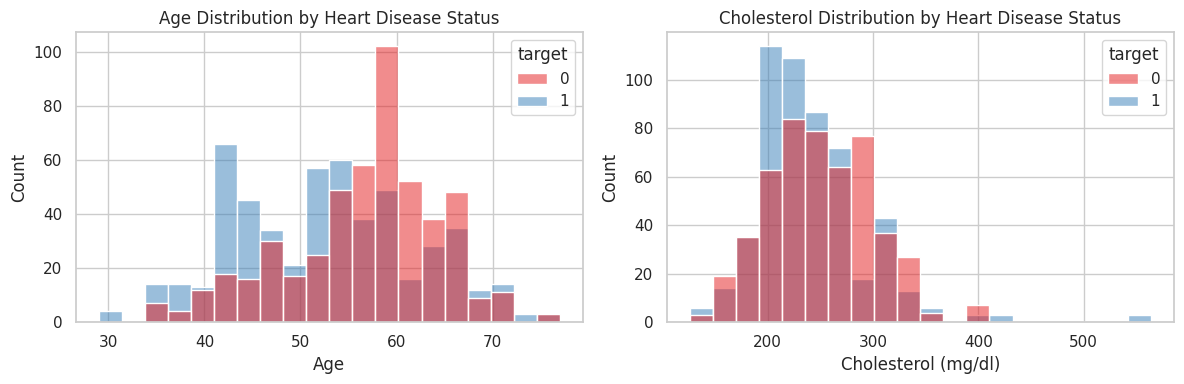

In [8]:
# ── STEP 3b: Plot Age and Cholesterol Distributions ─────────────────────────
# A histogram shows how the values of a feature are spread out.
# We look at age and cholesterol because these are well-known risk factors.
# The 'hue' argument colours each bar by the target column (0 = no disease, 1 = disease)
# so we can see if the distributions differ between the two groups.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x='age', hue='target', bins=20, ax=axes[0], palette='Set1')
axes[0].set_title('Age Distribution by Heart Disease Status')
axes[0].set_xlabel('Age')

sns.histplot(data=df, x='chol', hue='target', bins=20, ax=axes[1], palette='Set1')
axes[1].set_title('Cholesterol Distribution by Heart Disease Status')
axes[1].set_xlabel('Cholesterol (mg/dl)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_5775/3066724795.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['No Disease (0)', 'Disease (1)'], y=target_counts.values, palette='Set2')


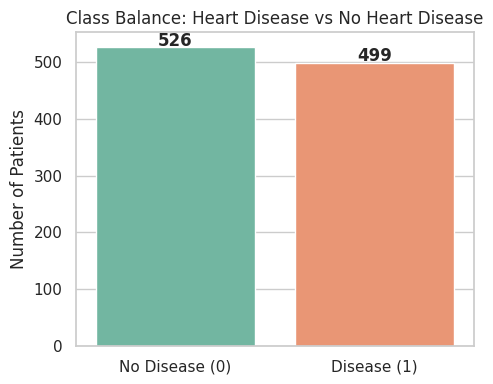

In [9]:
# ── STEP 3c: Class Balance Bar Chart ─────────────────────────────────────────
# If one class has many more samples than the other (class imbalance), the model
# might just predict the majority class for everything and still look 'accurate'.
# Always check that the classes are roughly balanced before modelling.

target_counts = df['target'].value_counts()

plt.figure(figsize=(5, 4))
sns.barplot(x=['No Disease (0)', 'Disease (1)'], y=target_counts.values, palette='Set2')
plt.title('Class Balance: Heart Disease vs No Heart Disease')
plt.ylabel('Number of Patients')
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# ── STEP 4: Feature and Target Split ─────────────────────────────────────────
# In supervised ML we always separate:
#   • X (features): the input columns the model uses to make predictions
#   • y (target): the column the model is trying to predict
#
# We drop 'target' from X because that's what we're predicting — if the model
# could see the answer during training it would just memorize it.

X = df.drop(columns=['target'])   # All columns except the target
y = df['target']                  # The column we want to predict

print(f'Features (X): {X.shape}')    # Should be (rows, 13) for the UCI dataset
print(f'Target (y): {y.shape}')
print(f'Feature names: {list(X.columns)}')

Features (X): (1025, 13)
Target (y): (1025,)
Feature names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [11]:
# ── STEP 5: StandardScaler Setup ────────────────────────────────────────────
# Some features in our dataset have very different value ranges:
#   • 'age' ranges from ~29 to ~77
#   • 'trestbps' (resting blood pressure) ranges from ~94 to ~200
#   • 'chol' (cholesterol) ranges from ~126 to ~564
#
# Logistic Regression uses gradient descent to find the best model parameters.
# If one feature has values of 500 and another has values of 1, the algorithm
# will be dominated by the large feature and may converge very slowly or give
# bad results. StandardScaler fixes this by transforming every feature so it
# has mean=0 and standard deviation=1. After scaling, all features are on the
# same playing field.
#
# IMPORTANT — We only *initialise* the scaler here.
# We must split the data first and then fit the scaler on the training set only.
# Fitting on all data before the split leaks test-set mean/std into training and
# can make evaluation results over-optimistic.

scaler = StandardScaler()
print('Scaler ready.')

Scaler ready.


In [12]:
# ── STEP 6: Train / Test Split and Feature Scaling ───────────────────────────
# We split the UNSCALED features first, then fit the scaler on training data
# only. This ensures the mean and standard deviation used for scaling are
# computed solely from training samples — no information from the test set
# bleeds into the model, keeping evaluation honest.
#
# stratify=y ensures both classes appear in the test set at the same
# ratio as the full dataset (important when classes are unequal in size).

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# fit_transform: learns mean/std from training rows, then scales them
X_train = scaler.fit_transform(X_train_raw)
# transform: applies the SAME mean/std to test rows (no re-fitting)
X_test  = scaler.transform(X_test_raw)

print(f'Train size: {X_train.shape[0]} samples')
print(f'Test  size: {X_test.shape[0]} samples')

Train size: 820 samples
Test  size: 205 samples


In [13]:
# ── STEP 7: Baseline — Logistic Regression ───────────────────────────────────
# We always start with a simple model as a 'baseline'. Any more complex model
# we train should beat this baseline, otherwise the added complexity isn't
# worth it. Logistic Regression is fast, interpretable, and often hard to beat
# on small tabular datasets.

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_acc = lr.score(X_test, y_test)   # .score() returns accuracy (% of correct predictions)
print(f'Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.1f}%)')

Logistic Regression Accuracy: 0.8098 (81.0%)


In [14]:
# ── STEP 8: Compare with Random Forest ───────────────────────────────────────
# Random Forest is an ensemble method: it builds many decision trees and
# combines their votes. Each tree is trained on a random subset of the data
# and a random subset of features, which reduces overfitting.
#
# Key advantages over Logistic Regression:
#   • Handles non-linear relationships between features
#   • Naturally robust to outliers
#   • Does not require feature scaling (trees split on thresholds, not distances)
#
# n_estimators=100 → build 100 decision trees and majority-vote for predictions

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_acc = rf.score(X_test, y_test)
print(f'Random Forest Accuracy      : {rf_acc:.4f} ({rf_acc*100:.1f}%)')
print(f'Logistic Regression Accuracy: {lr_acc:.4f} ({lr_acc*100:.1f}%)')

best_model = rf if rf_acc >= lr_acc else lr
best_name  = 'Random Forest' if rf_acc >= lr_acc else 'Logistic Regression'
print(f'\n🏆 Best model: {best_name}')

Random Forest Accuracy      : 1.0000 (100.0%)
Logistic Regression Accuracy: 0.8098 (81.0%)

🏆 Best model: Random Forest


=== Classification Report (Random Forest) ===
              precision    recall  f1-score   support

  No Disease       1.00      1.00      1.00       100
     Disease       1.00      1.00      1.00       105

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



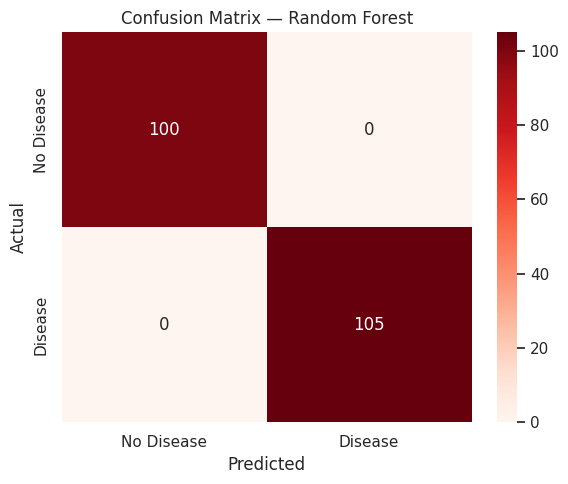

In [15]:
# ── STEP 9: Classification Report and Confusion Matrix ───────────────────────
# We now evaluate our best model in more detail.
#
# In medical contexts, errors have real consequences:
#   • False Negative: we predict 'no disease' but patient actually has it — DANGEROUS
#   • False Positive: we predict 'disease' but patient is healthy — causes unnecessary tests
# Recall for class 1 tells us: out of all patients with disease, how many did we catch?

y_pred_best = best_model.predict(X_test)

print(f'=== Classification Report ({best_name}) ===')
print(classification_report(y_test, y_pred_best, target_names=['No Disease', 'Disease']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

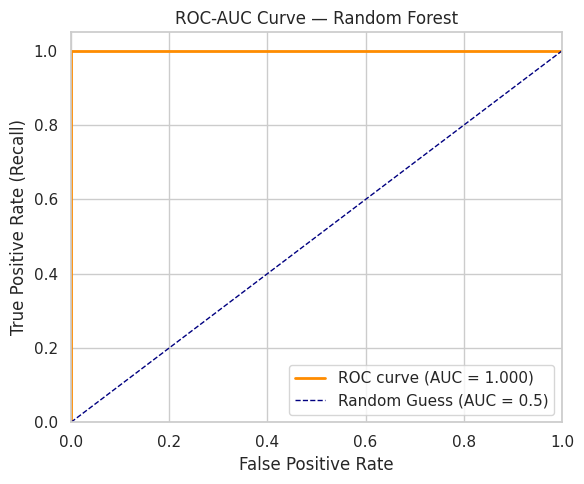

AUC Score: 1.0000


In [16]:
# ── STEP 10: ROC-AUC Curve ────────────────────────────────────────────────────
# The ROC (Receiver Operating Characteristic) curve shows the trade-off between:
#   • True Positive Rate (Recall): proportion of actual positives correctly identified
#   • False Positive Rate: proportion of actual negatives incorrectly flagged as positive
#
# AUC = Area Under the Curve. It ranges from 0.5 to 1.0:
#   • AUC = 0.5 → model is no better than random guessing
#   • AUC = 1.0 → perfect classifier (catches all positives with zero false alarms)
#   • AUC > 0.8 → considered a good model for medical applications
#
# We use predict_proba to get the model's confidence score (not just 0/1 prediction)
# because the ROC curve is built by varying the decision threshold.

y_prob = best_model.predict_proba(X_test)[:, 1]   # Probability of class 1 (Disease)
auc_score = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title(f'ROC-AUC Curve — {best_name}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
print(f'AUC Score: {auc_score:.4f}')

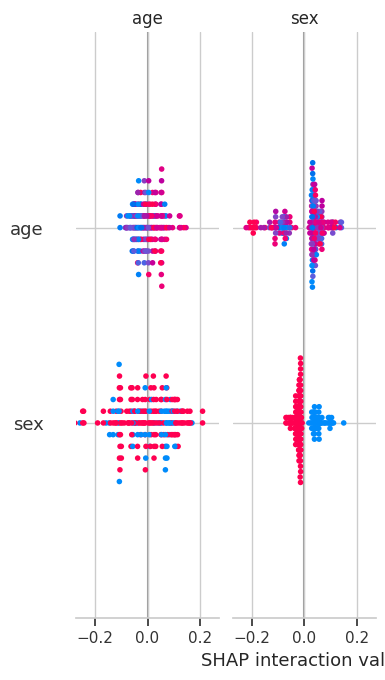


The longer the bar, the more important the feature is to the model.


In [17]:
# ── STEP 11: SHAP Feature Importance ─────────────────────────────────────────
# SHAP (SHapley Additive exPlanations) tells us HOW MUCH each feature
# contributed to a particular prediction. It comes from game theory:
# each feature is like a player in a team, and SHAP calculates each player's
# fair contribution to the final score.
#
# A SHAP bar chart shows the MEAN ABSOLUTE SHAP value for each feature across
# all test samples — a higher bar means that feature has a bigger average impact
# on the model's output. This helps doctors and researchers understand which
# health measurements matter most.

# We use TreeExplainer for tree-based models (Random Forest) because it's fast.
# For Logistic Regression, we would use LinearExplainer instead.
if best_name == 'Random Forest':
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.LinearExplainer(best_model, X_train)

shap_values = explainer.shap_values(X_test)

# For multi-output (binary classification), shap_values is a list; take class 1
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Bar plot: mean absolute SHAP value per feature
shap.summary_plot(sv, X_test, feature_names=list(X.columns), plot_type='bar', show=True)
print('\nThe longer the bar, the more important the feature is to the model.')

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)
best_acc = best_rf.score(X_test, y_test)
print(f"Tuned Random Forest Accuracy: {best_acc:.4f}")

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.9853658536585366
Tuned Random Forest Accuracy: 1.0000


In [18]:
!pip install xgboost

from xgboost import XGBClassifier

In [22]:
xgb = XGBClassifier( eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

xgb_acc = xgb.score(X_test, y_test)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

XGBoost Accuracy: 1.0000


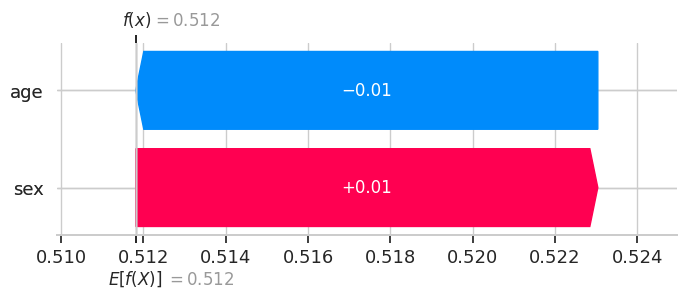

In [25]:
import shap
import pandas as pd

X_test_df = pd.DataFrame(X_test, columns=X.columns)
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# Pick one patient (index 0)
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],

        feature_names=X.columns
    )
)

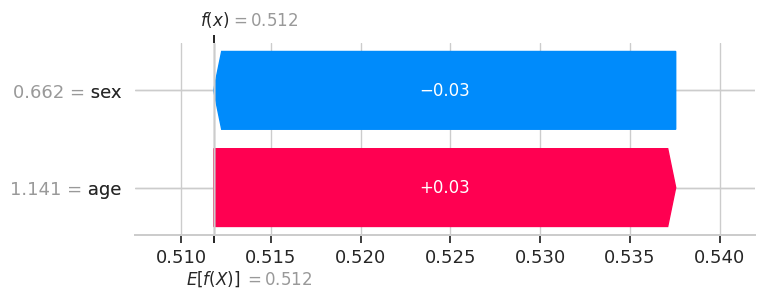

In [26]:
# Check another patient
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[1][10],
        base_values=explainer.expected_value[1],
        data=X_test_df.iloc[10],
        feature_names=X.columns
    )
)

In [27]:
print("Logistic Regression:", lr_acc)
print("Random Forest:", rf_acc)
print("Tuned RF:", best_acc)
print("XGBoost:", xgb_acc)

Logistic Regression: 0.8097560975609757
Random Forest: 1.0
Tuned RF: 1.0
XGBoost: 1.0
